# DocForge — Preprocessing

---
### Sections
1. Install & Config
2. Load Dataset
3. Flatten Array Columns
4. Basic Cleaning
5. Code Normalization
6. Docstring Normalization
7. Length Check After Cleaning
8. Prompt Formatting — CodeT5
9. Prompt Formatting — Llama 3.1 8B
10. Token Length Verification
11. Save to Disk
12. Final Summary

---
## Section 1 — Install & Config

In [101]:
!pip install datasets transformers sentencepiece -q

import re
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from datasets import load_dataset, Dataset, DatasetDict

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

In [102]:
# Column names
CODE_COL   = 'function_code'
DOC_COL    = 'documentation'
LANG_COL   = 'language'
QUAL_COL   = 'quality_score'
CC_COL     = 'complexity'
ANN_COL    = 'has_type_hints'
REPO_COL   = 'repo_name'
STYLE_COL  = 'docstring_style'

# Length filters
MIN_CODE_CHARS  = 50
MAX_CODE_CHARS  = 4000
MIN_DOC_CHARS   = 10
MAX_DOC_CHARS   = 1500
MIN_QUALITY     = 6.0

# Tokenizer limits (from EDA coverage table)
CODET5_MAX_INPUT  = 512
CODET5_MAX_TARGET = 256
LLAMA_MAX_SEQ     = 1024

RANDOM_SEED = 42
OUTPUT_DIR  = '/kaggle/working/processed'
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Config set:')
print(f'  Code col          : {CODE_COL}')
print(f'  Doc col           : {DOC_COL}')
print(f'  CODET5_MAX_INPUT  : {CODET5_MAX_INPUT}')
print(f'  CODET5_MAX_TARGET : {CODET5_MAX_TARGET}')
print(f'  Output dir        : {OUTPUT_DIR}')

Config set:
  Code col          : function_code
  Doc col           : documentation
  CODET5_MAX_INPUT  : 512
  CODET5_MAX_TARGET : 256
  Output dir        : /kaggle/working/processed


---
## Section 2 — Load Dataset

In [103]:
def load_with_retry(dataset_name, retries=3, wait=5):
    for attempt in range(1, retries + 1):
        try:
            ds = load_dataset(dataset_name)
            print(f'Loaded on attempt {attempt}')
            return ds
        except Exception as e:
            print(f'Attempt {attempt} failed: {e}')
            if attempt < retries:
                print(f'Waiting {wait}s before retrying...')
                time.sleep(wait)
    raise RuntimeError(f'Failed to load {dataset_name} after {retries} attempts')


dataset = load_with_retry('kaanrkaraman/code2doc')

train_df = dataset['train'].to_pandas()
test_df  = dataset['test'].to_pandas()

print(f'\nSplit sizes:')
print(f'  Train : {len(train_df):,}')
print(f'  Test  : {len(test_df):,}')

Loaded on attempt 1

Split sizes:
  Train : 10,684
  Test  : 1,340


---
## Section 3 — Flatten Array Columns

In [104]:
def flatten_array_cols(df):
    flattened = []
    for col in df.columns:
        first_val = df[col].dropna().iloc[0] if df[col].dropna().shape[0] > 0 else None
        if isinstance(first_val, (list, np.ndarray)):
            df[col] = df[col].apply(
                lambda x: ', '.join(str(i) for i in x) if isinstance(x, (list, np.ndarray)) else x
            )
            flattened.append(col)
    if flattened:
        print(f'  Flattened columns: {flattened}')
    else:
        print('  No array columns found.')
    return df


print('Train:')
train_df = flatten_array_cols(train_df)
print('Test:')
test_df  = flatten_array_cols(test_df)

Train:
  Flattened columns: ['parameters']
Test:
  Flattened columns: ['parameters']


---
## Section 4 — Basic Cleaning

In [105]:
LANG_ALIASES = {'c++': 'cpp', 'c#': 'csharp', 'typescript': 'typescript', 'javascript': 'javascript'}

def basic_clean(df, split_name):
    n0 = len(df)

    # 1. Drop nulls in code or doc
    df = df.dropna(subset=[CODE_COL, DOC_COL])
    print(f'[{split_name}] After null drop       : {len(df):,} (removed {n0 - len(df):,})')

    # 2. Convert to string and strip
    df[CODE_COL] = df[CODE_COL].astype(str).str.strip()
    df[DOC_COL]  = df[DOC_COL].astype(str).str.strip()

    # 3. Drop empty strings
    n1 = len(df)
    df = df[(df[CODE_COL] != '') & (df[DOC_COL] != '')]
    print(f'[{split_name}] After empty drop      : {len(df):,} (removed {n1 - len(df):,})')

    # 4. Normalize language labels
    df[LANG_COL] = df[LANG_COL].str.lower().str.strip()
    df[LANG_COL] = df[LANG_COL].replace(LANG_ALIASES)

    # 5. Quality filter
    n2 = len(df)
    df = df[df[QUAL_COL] >= MIN_QUALITY]
    print(f'[{split_name}] After quality filter  : {len(df):,} (removed {n2 - len(df):,})')

    # 6. Fill null parameters
    if 'parameters' in df.columns:
        df['parameters'] = df['parameters'].fillna('')

    print(f'[{split_name}] Final                 : {len(df):,} rows  (total removed: {n0 - len(df):,})')
    return df.reset_index(drop=True)


train_df = basic_clean(train_df, 'train')
test_df  = basic_clean(test_df,  'test')

[train] After null drop       : 10,684 (removed 0)
[train] After empty drop      : 10,684 (removed 0)
[train] After quality filter  : 10,684 (removed 0)
[train] Final                 : 10,684 rows  (total removed: 0)
[test] After null drop       : 1,340 (removed 0)
[test] After empty drop      : 1,340 (removed 0)
[test] After quality filter  : 1,340 (removed 0)
[test] Final                 : 1,340 rows  (total removed: 0)


---
## Section 5 — Code Normalization

In [106]:
def normalize_code(code: str) -> str:
    code = code.replace('\r\n', '\n').replace('\r', '\n')
    code = code.replace('\t', '    ')
    code = '\n'.join(line.rstrip() for line in code.split('\n'))
    code = re.sub(r'\n{3,}', '\n\n', code)
    return code.strip()


def apply_code_normalization(df, split_name):
    df['code_clean'] = df[CODE_COL].apply(normalize_code)
    df['code_len']   = df['code_clean'].str.len()
    n0 = len(df)
    df = df[(df['code_len'] >= MIN_CODE_CHARS) & (df['code_len'] <= MAX_CODE_CHARS)]
    print(f'[{split_name}] Code length filter: {n0:,} → {len(df):,} (removed {n0 - len(df):,})')
    return df.reset_index(drop=True)


train_df = apply_code_normalization(train_df, 'train')
test_df  = apply_code_normalization(test_df,  'test')

# Show before/after for one row
row = train_df.iloc[0]
print('\n--- Original code (first 300 chars) ---')
print(str(row[CODE_COL])[:300])
print('\n--- Cleaned code (first 300 chars) ---')
print(str(row['code_clean'])[:300])

[train] Code length filter: 10,684 → 10,434 (removed 250)
[test] Code length filter: 1,340 → 1,314 (removed 26)

--- Original code (first 300 chars) ---
function parseTypeParameter(): TypeParameterDeclaration {
        const pos = getNodePos();
        const modifiers = parseModifiers(/*allowDecorators*/ false, /*permitConstAsModifier*/ true);
        const name = parseIdentifier();
        let constraint: TypeNode | undefined;
        let expr

--- Cleaned code (first 300 chars) ---
function parseTypeParameter(): TypeParameterDeclaration {
        const pos = getNodePos();
        const modifiers = parseModifiers(/*allowDecorators*/ false, /*permitConstAsModifier*/ true);
        const name = parseIdentifier();
        let constraint: TypeNode | undefined;
        let expressio


---
## Section 6 — Docstring Normalization

In [107]:
def normalize_docstring(doc: str) -> str:
    # Strip Python triple-quote wrappers
    doc = re.sub(r'^\s*"""\s*', '', doc)
    doc = re.sub(r'\s*"""\s*$', '', doc)
    doc = re.sub(r"^\s*'''\s*", '', doc)
    doc = re.sub(r"\s*'''\s*$", '', doc)

    # Strip JavaDoc /** */ wrappers and leading * per line
    doc = re.sub(r'^\s*/\*\*\s*', '', doc)
    doc = re.sub(r'\s*\*/\s*$', '', doc)
    doc = re.sub(r'^\s*\*\s?', '', doc, flags=re.MULTILINE)

    # General cleanup
    doc = re.sub(r'\n{3,}', '\n\n', doc)
    doc = doc.replace('\t', ' ')
    doc = re.sub(r' {2,}', ' ', doc)
    return doc.strip()


def apply_doc_normalization(df, split_name):
    df['doc_clean'] = df[DOC_COL].apply(normalize_docstring)
    df['doc_len']   = df['doc_clean'].str.len()
    n0 = len(df)
    df = df[(df['doc_len'] >= MIN_DOC_CHARS) & (df['doc_len'] <= MAX_DOC_CHARS)]
    print(f'[{split_name}] Doc length filter: {n0:,} → {len(df):,} (removed {n0 - len(df):,})')
    return df.reset_index(drop=True)


train_df = apply_doc_normalization(train_df, 'train')
test_df  = apply_doc_normalization(test_df,  'test')

# Show a Java example to see JavaDoc cleaning
java_rows = train_df[train_df[LANG_COL] == 'java']
if len(java_rows) > 0:
    row = java_rows.iloc[0]
    print('\n--- Raw Java documentation ---')
    print(str(row[DOC_COL])[:400])
    print('\n--- Cleaned doc_clean ---')
    print(str(row['doc_clean'])[:400])

[train] Doc length filter: 10,434 → 10,214 (removed 220)
[test] Doc length filter: 1,314 → 1,293 (removed 21)

--- Raw Java documentation ---
Return the column of the text resource where the property originated.
@return the column number (zero indexed)

--- Cleaned doc_clean ---
Return the column of the text resource where the property originated.
@return the column number (zero indexed)


---
## Section 7 — Length Check After Cleaning

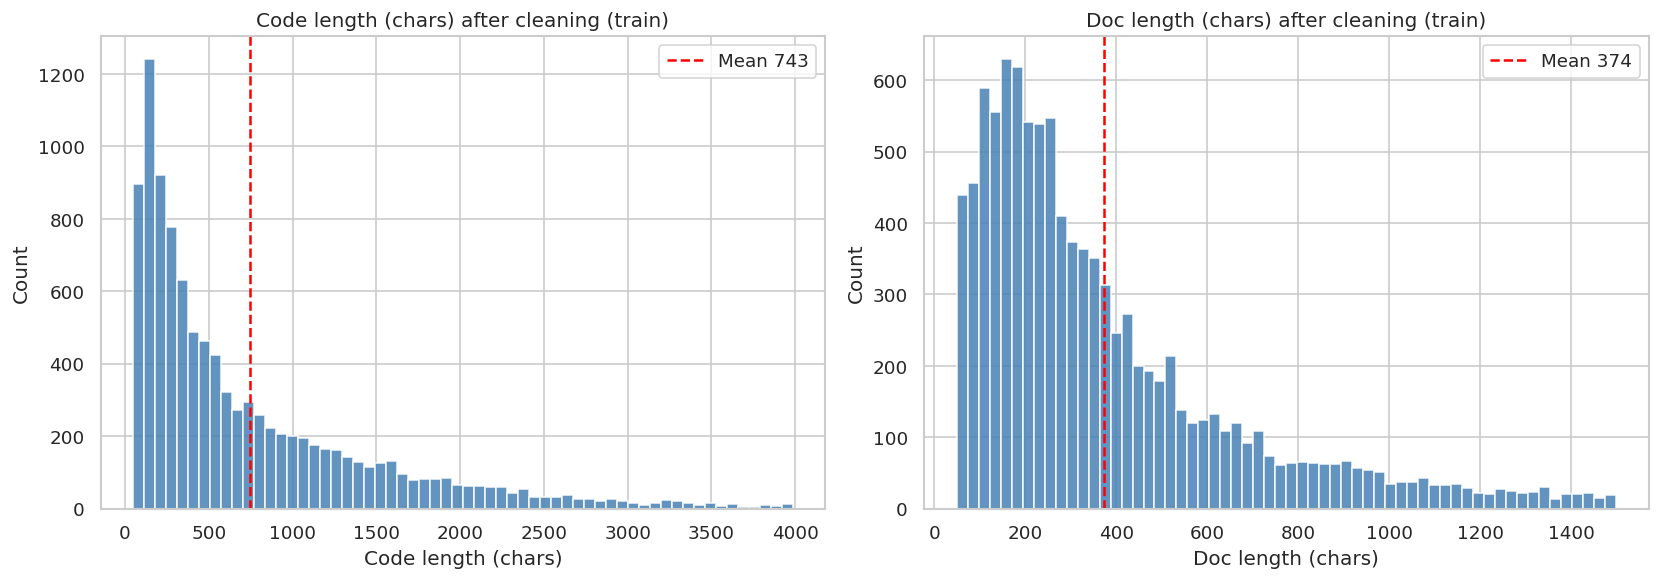

Final split sizes:
  Train : 10,214
  Test  : 1,293

Language distribution:
  train: {'java': np.float64(61.9), 'python': np.float64(26.2), 'typescript': np.float64(6.6), 'javascript': np.float64(4.1), 'cpp': np.float64(1.2)}
  test: {'java': np.float64(61.6), 'python': np.float64(26.5), 'typescript': np.float64(6.4), 'javascript': np.float64(4.3), 'cpp': np.float64(1.2)}


In [108]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in [
    (axes[0], 'code_len', 'Code length (chars)'),
    (axes[1], 'doc_len',  'Doc length (chars)')
]:
    ax.hist(train_df[col], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(train_df[col].mean(), color='red', linestyle='--',
               label=f'Mean {train_df[col].mean():.0f}')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.set_title(f'{label} after cleaning (train)')
    ax.legend()

plt.tight_layout()
plt.show()

print('Final split sizes:')
print(f'  Train : {len(train_df):,}')
print(f'  Test  : {len(test_df):,}')

print('\nLanguage distribution:')
for split_name, split_df in [('train', train_df), ('test', test_df)]:
    dist = split_df[LANG_COL].value_counts(normalize=True).mul(100).round(1)
    print(f'  {split_name}: {dict(dist)}')

---
## Section 8 — Prompt Formatting: CodeT5

In [109]:
def make_codet5_input(row) -> str:
    return f"Summarize {row[LANG_COL]}: {row['code_clean']}"


for split_df in [train_df, test_df]:
    split_df['codet5_input']  = split_df.apply(make_codet5_input, axis=1)
    split_df['codet5_target'] = split_df['doc_clean']

print('--- Example CodeT5 input (first 300 chars) ---')
print(train_df['codet5_input'].iloc[0][:300])
print('\n--- Example CodeT5 target (first 300 chars) ---')
print(train_df['codet5_target'].iloc[0][:300])

--- Example CodeT5 input (first 300 chars) ---
Summarize typescript: function parseTypeParameter(): TypeParameterDeclaration {
        const pos = getNodePos();
        const modifiers = parseModifiers(/*allowDecorators*/ false, /*permitConstAsModifier*/ true);
        const name = parseIdentifier();
        let constraint: TypeNode | undefined;

--- Example CodeT5 target (first 300 chars) ---
Reports a diagnostic error for the current token being an invalid name.

@param blankDiagnostic Diagnostic to report for the case of the name being blank (matched tokenIfBlankName).
@param nameDiagnostic Diagnostic to report for all other cases.
@param tokenIfBlankName Current token if the name w


---
## Section 9 — Prompt Formatting: Llama 3.1 8B

In [110]:
SYSTEM_PROMPT = (
    "You are an expert software documentation writer. "
    "Given a function's source code, generate a complete docstring that includes: "
    "a clear description of what the function does, "
    "an explanation of each parameter, "
    "and the return value. "
    "Be concise, accurate, and follow standard documentation conventions."
)


def make_llama_prompt(row, include_response: bool = True) -> str:
    user_msg = f"Generate documentation for the following {row[LANG_COL]} function:\n\n{row['code_clean']}"

    prompt = (
        "<|begin_of_text|>"
        "<|start_header_id|>system<|end_header_id|>\n\n"
        f"{SYSTEM_PROMPT}<|eot_id|>"
        "<|start_header_id|>user<|end_header_id|>\n\n"
        f"{user_msg}<|eot_id|>"
        "<|start_header_id|>assistant<|end_header_id|>\n\n"
    )

    if include_response:
        prompt += f"{row['doc_clean']}<|eot_id|>"

    return prompt


for split_df in [train_df, test_df]:
    split_df['llama_prompt_train'] = split_df.apply(lambda r: make_llama_prompt(r, include_response=True),  axis=1)
    split_df['llama_prompt_infer'] = split_df.apply(lambda r: make_llama_prompt(r, include_response=False), axis=1)

print('--- Example Llama training prompt (first 600 chars) ---')
print(train_df['llama_prompt_train'].iloc[0][:600])

--- Example Llama training prompt (first 600 chars) ---
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are an expert software documentation writer. Given a function's source code, generate a complete docstring that includes: a clear description of what the function does, an explanation of each parameter, and the return value. Be concise, accurate, and follow standard documentation conventions.<|eot_id|><|start_header_id|>user<|end_header_id|>

Generate documentation for the following typescript function:

function parseTypeParameter(): TypeParameterDeclaration {
        const pos = getNodePos();
        const modifiers = parseModi


---
## Section 10 — Token Length Verification

In [111]:
sample = train_df.sample(2000, random_state=42).copy()

sample['ct_input_tokens']  = sample['codet5_input'].str.len()       // 4
sample['ct_target_tokens'] = sample['codet5_target'].str.len()      // 4
sample['llama_tokens']     = sample['llama_prompt_train'].str.len() // 4

print('CodeT5 input token coverage:')
for limit in [256, 512, 1024]:
    pct = (sample['ct_input_tokens'] <= limit).mean() * 100
    print(f'  <= {limit:4d} : {pct:.1f}%')

print('\nCodeT5 target token coverage:')
for limit in [128, 256, 512]:
    pct = (sample['ct_target_tokens'] <= limit).mean() * 100
    print(f'  <= {limit:3d} : {pct:.1f}%')

print('\nLlama full sequence token coverage:')
for limit in [512, 1024, 2048]:
    pct = (sample['llama_tokens'] <= limit).mean() * 100
    print(f'  <= {limit:4d} : {pct:.1f}%')

ct_input_ok = (sample['ct_input_tokens'] <= CODET5_MAX_INPUT).mean() * 100
print(f'\nCODET5_MAX_INPUT={CODET5_MAX_INPUT} covers {ct_input_ok:.1f}% of samples '
      f'({"✓ >= 90%" if ct_input_ok >= 90 else "✗ below 90%"})')

CodeT5 input token coverage:
  <=  256 : 73.0%
  <=  512 : 92.7%
  <= 1024 : 100.0%

CodeT5 target token coverage:
  <= 128 : 76.8%
  <= 256 : 95.2%
  <= 512 : 100.0%

Llama full sequence token coverage:
  <=  512 : 76.1%
  <= 1024 : 97.7%
  <= 2048 : 100.0%

CODET5_MAX_INPUT=512 covers 92.7% of samples (✓ >= 90%)


---
## Section 11 — Save to Disk

In [112]:
META_COLS = [c for c in ['function_name', LANG_COL, QUAL_COL, CC_COL, ANN_COL, REPO_COL, STYLE_COL]
             if c in train_df.columns]

CODET5_COLS = list(dict.fromkeys(META_COLS + ['code_clean', 'doc_clean', 'codet5_input', 'codet5_target']))
CODET5_COLS = [c for c in CODET5_COLS if c in train_df.columns]

LLAMA_COLS  = list(dict.fromkeys(META_COLS + ['code_clean', 'doc_clean', 'llama_prompt_train', 'llama_prompt_infer']))
LLAMA_COLS  = [c for c in LLAMA_COLS if c in train_df.columns]

ALL_COLS = list(dict.fromkeys(CODET5_COLS + LLAMA_COLS))

# --- CSV ---
for name, split_df in [('train', train_df), ('test', test_df)]:
    path = os.path.join(OUTPUT_DIR, f'{name}.csv')
    split_df[ALL_COLS].to_csv(path, index=False)
    print(f'Saved: {path}')

# --- JSONL ---
for name, split_df in [('train', train_df), ('test', test_df)]:
    path = os.path.join(OUTPUT_DIR, f'{name}_llama.jsonl')
    with open(path, 'w') as f:
        for _, row in split_df[LLAMA_COLS].iterrows():
            f.write(json.dumps(row.to_dict()) + '\n')
    print(f'Saved: {path}')

# --- HuggingFace DatasetDicts ---
codet5_dataset = DatasetDict({
    'train':      Dataset.from_pandas(train_df[CODET5_COLS].reset_index(drop=True)),
    'test':       Dataset.from_pandas(test_df[CODET5_COLS].reset_index(drop=True)),
})
codet5_path = os.path.join(OUTPUT_DIR, 'codet5_dataset')
codet5_dataset.save_to_disk(codet5_path)
print(f'Saved: {codet5_path}')

llama_dataset = DatasetDict({
    'train':      Dataset.from_pandas(train_df[LLAMA_COLS].reset_index(drop=True)),
    'test':       Dataset.from_pandas(test_df[LLAMA_COLS].reset_index(drop=True)),
})
llama_path = os.path.join(OUTPUT_DIR, 'llama_dataset')
llama_dataset.save_to_disk(llama_path)
print(f'Saved: {llama_path}')

# --- Config JSON ---
config = {
    'columns': {'code': CODE_COL, 'doc': DOC_COL, 'lang': LANG_COL,
                'quality': QUAL_COL, 'complexity': CC_COL},
    'split_sizes': {'train': len(train_df), 'test': len(test_df)},
    'language_dist_train': train_df[LANG_COL].value_counts().to_dict(),
    'filters': {
        'min_code_chars': MIN_CODE_CHARS, 'max_code_chars': MAX_CODE_CHARS,
        'min_doc_chars': MIN_DOC_CHARS,  'max_doc_chars': MAX_DOC_CHARS,
        'min_quality': MIN_QUALITY
    },
    'max_lengths': {
        'codet5_input': CODET5_MAX_INPUT,
        'codet5_target': CODET5_MAX_TARGET,
        'llama_seq': LLAMA_MAX_SEQ
    }
}
config_path = os.path.join(OUTPUT_DIR, 'preprocessing_config.json')
with open(config_path, 'w') as f:
    json.dump(config, f, indent=2)
print(f'Saved: {config_path}')

Saved: /kaggle/working/processed/train.csv
Saved: /kaggle/working/processed/test.csv
Saved: /kaggle/working/processed/train_llama.jsonl
Saved: /kaggle/working/processed/test_llama.jsonl


Saving the dataset (0/1 shards):   0%|          | 0/10214 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1293 [00:00<?, ? examples/s]

Saved: /kaggle/working/processed/codet5_dataset


Saving the dataset (0/1 shards):   0%|          | 0/10214 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1293 [00:00<?, ? examples/s]

Saved: /kaggle/working/processed/llama_dataset
Saved: /kaggle/working/processed/preprocessing_config.json


---
## Section 12 — Final Summary

In [113]:
print('=' * 65)
print('        DOCFORGE — PREPROCESSING SUMMARY')
print('=' * 65)
print(f"""
Cleaning Steps Applied
  1. Flattened array columns        : yes
  2. Dropped null rows              : yes
  3. Normalized language labels     : yes
  4. Quality filter (>= {MIN_QUALITY})       : yes
  5. Code normalization             : yes
  6. Code length filter [{MIN_CODE_CHARS}, {MAX_CODE_CHARS}]  : yes
  7. Docstring normalization        : yes
  8. Doc length filter  [{MIN_DOC_CHARS}, {MAX_DOC_CHARS}]   : yes

Final Dataset Sizes
  Train : {len(train_df):,}
  Test  : {len(test_df):,}

Files Saved
  CSV files        : train.csv, val.csv, test.csv
  JSONL files      : train_llama.jsonl, val_llama.jsonl, test_llama.jsonl
  HF DatasetDicts  : codet5_dataset/, llama_dataset/
  Config           : preprocessing_config.json

Notebook 3 Quick Reference
  CodeT5 input column   : 'codet5_input'
  CodeT5 target column  : 'codet5_target'
  CodeT5 max_input      : {CODET5_MAX_INPUT}
  CodeT5 max_target     : {CODET5_MAX_TARGET}

  Llama train column    : 'llama_prompt_train'
  Llama infer column    : 'llama_prompt_infer'
  Llama max_seq         : {LLAMA_MAX_SEQ}
""")
print('=' * 65)

        DOCFORGE — PREPROCESSING SUMMARY

Cleaning Steps Applied
  1. Flattened array columns        : yes
  2. Dropped null rows              : yes
  3. Normalized language labels     : yes
  4. Quality filter (>= 6.0)       : yes
  5. Code normalization             : yes
  6. Code length filter [50, 4000]  : yes
  7. Docstring normalization        : yes
  8. Doc length filter  [10, 1500]   : yes

Final Dataset Sizes
  Train : 10,214
  Test  : 1,293

Files Saved
  CSV files        : train.csv, val.csv, test.csv
  JSONL files      : train_llama.jsonl, val_llama.jsonl, test_llama.jsonl
  HF DatasetDicts  : codet5_dataset/, llama_dataset/
  Config           : preprocessing_config.json

Notebook 3 Quick Reference
  CodeT5 input column   : 'codet5_input'
  CodeT5 target column  : 'codet5_target'
  CodeT5 max_input      : 512
  CodeT5 max_target     : 256

  Llama train column    : 'llama_prompt_train'
  Llama infer column    : 'llama_prompt_infer'
  Llama max_seq         : 1024

